In [3]:
from diffusers import DDPMPipeline

C:\Users\Shipu\anaconda3\envs\diffusers_use\lib\site-packages\huggingface_hub\file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

C:\Users\Shipu\anaconda3\envs\diffusers_use\lib\site-packages\diffusers\models\attention_processor.py:1279: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at ..\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:455.)
  hidden_states = F.scaled_dot_product_attention(


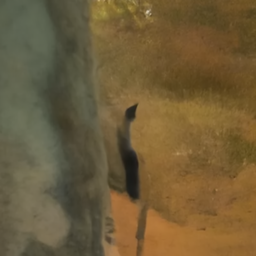

In [4]:
ddpm = DDPMPipeline.from_pretrained("google/ddpm-cat-256", use_safetensors=True).to("cuda")
image = ddpm(num_inference_steps=25).images[0]
image

在上述的示例中包含pipeline包含一个Unet2DModel和一个DDPMScheduler，管道获取所需输出大小的随机噪声并将其多次传递到模型中对图像进行降噪。在每个时间步模型预测noise residual，scheduler用它来预测噪声较小的图像，pipeline重复此过程，直到达到指定数量推理步骤的结尾

下面编写自己的去噪过程，重新分别创建model和scheduler

In [5]:
from diffusers import DDPMScheduler,UNet2DModel

加载Scheduler和model

In [6]:
scheduler=DDPMScheduler.from_pretrained("google/ddpm-cat-256")
model = UNet2DModel.from_pretrained("google/ddpm-cat-256", use_safetensors=True).to("cuda")

设置运行降噪过程的时间步长数

In [9]:
scheduler.set_timesteps(50)
scheduler.timesteps

tensor([980, 960, 940, 920, 900, 880, 860, 840, 820, 800, 780, 760, 740, 720,
        700, 680, 660, 640, 620, 600, 580, 560, 540, 520, 500, 480, 460, 440,
        420, 400, 380, 360, 340, 320, 300, 280, 260, 240, 220, 200, 180, 160,
        140, 120, 100,  80,  60,  40,  20,   0])

设置调度程序时间步长会创建一个张量，其中元素分布均匀，在上例中是50，每个元素对应于模型对图像进行降噪的
时间步长，在稍后创建去噪循环的时候将遍历这个张量对图像进行降噪

下面产生一些和所需输出形状相同的随机噪声

In [11]:
import torch
sample_size=model.config.sample_size # 256
noise=torch.randn((1,3,sample_size,sample_size),device="cuda")

下面，编写一个循环来迭代时间步长。在每一个时间步model使用UNet2DModel.forward()传递并返回noisy residual。scheduler的step()方法接受noisy residual,timestep和input并预测前一个时间步长的图像，这个输出将作为循环模型的下一个输入，一直重复到循环结束

In [13]:
input=noise

for t in scheduler.timesteps:
    with torch.no_grad():
        noisy_residual=model(input,t).sample # 感觉这里是得到加的原始噪声
    
    # 由原始噪声xt来计算x0，根据公式算x_t-1
    previous_noisy_sample=scheduler.step(noisy_residual,t,input).prev_sample 
    

    input=previous_noisy_sample

上面的模式是整个去噪的过程，可以使用相同的模式来编写任何扩散系统

最后一步是将降噪输出转化为图像

In [14]:
from PIL import Image
import numpy as np

torch.Size([1, 3, 256, 256])


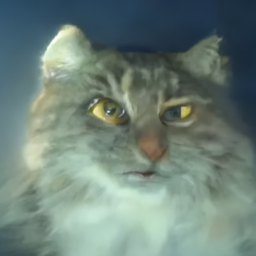

In [24]:
print(input.shape)
image=(input/2+0.5).clamp(0,1).squeeze()
image = (image.permute(1, 2, 0) * 255).round().to(torch.uint8).cpu().numpy()
image = Image.fromarray(image)
image

下一篇请参考：构建stable diffusion pipeline